# 02. Baseline-модели
Обучаем DummyClassifier и LogisticRegression.
Данные загружаются из `data/processed/`, созданных `preprocessing.py`.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Определяем корень проекта (на один уровень выше папки notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Импортируем функции из src.modeling
from src.modeling import load_processed_data, train_baseline_models, evaluate_models, save_model

sns.set_style('whitegrid')

# Проверим, видит ли Python папку data/processed
processed_path = os.path.join(PROJECT_ROOT, 'data', 'processed')
if os.path.exists(processed_path):
    print('Файлы в data/processed:', os.listdir(processed_path))
else:
    print('Папка data/processed не найдена! Запусти preprocessing.py.')
print('PROJECT_ROOT:', PROJECT_ROOT)

Файлы в data/processed: ['.gitkeep', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']
PROJECT_ROOT: c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv


### Загрузка обработанных данных
Функция `load_processed_data` из `modeling.py` использует путь относительно самого модуля, поэтому данные будут найдены даже без явного указания PROJECT_ROOT.

In [2]:
X_train, X_test, y_train, y_test = load_processed_data()

Данные загружены: train=(8000, 30), test=(2000, 30)


### Обучение моделей

In [3]:
models = train_baseline_models(X_train, y_train)

Модели обучены.


### Оценка и сравнение

In [4]:
results_df = evaluate_models(models, X_test, y_test)
results_df


--- Dummy (most_frequent) ---
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

Матрица ошибок:
[[1601    0]
 [ 399    0]]

--- Logistic Regression ---
              precision    recall  f1-score   support

          No       0.80      0.52      0.63      1601
         Yes       0.20      0.48      0.28       399

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.51      0.56      2000

Матрица ошибок:
[[835 766]
 [206 193]]


c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

,Модель,Accuracy,F1-score
0,Dummy (most_frequent),0.8005,0.000000
1,Logistic Regression,0.5140,0.284242


c:\Users\Пользователь\Desktop\Y4\hse\ml\project\hseml-group-project-justlevvv\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


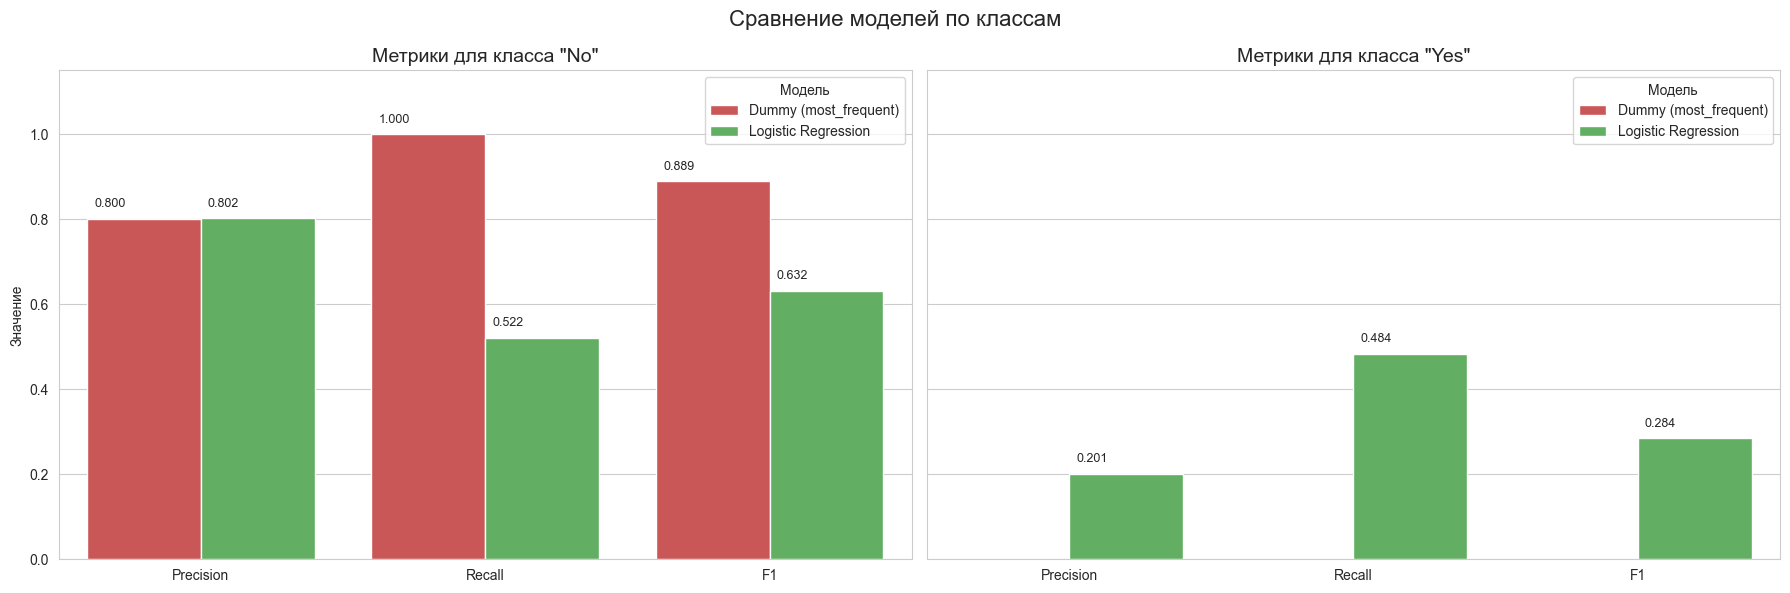

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Собираем метрики для обоих классов
classes = [0, 1]
class_names = ['No', 'Yes']
metrics_by_class = {name: [] for name in class_names}

for name, model in models.items():
    y_pred = model.predict(X_test)
    for cls, cls_name in zip(classes, class_names):
        prec = precision_score(y_test, y_pred, pos_label=cls)
        rec = recall_score(y_test, y_pred, pos_label=cls)
        f1 = f1_score(y_test, y_pred, pos_label=cls)
        metrics_by_class[cls_name].append({
            'Model': name,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

# Создаём фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, cls_name in zip(axes, class_names):
    df_cls = pd.DataFrame(metrics_by_class[cls_name])
    melted = df_cls.melt(id_vars='Model', var_name='Metric', value_name='Value')
    sns.barplot(x='Metric', y='Value', hue='Model', data=melted,
                palette=['#dd4444', '#55bb55'], ax=ax)
    ax.set_title(f'Метрики для класса "{cls_name}"', fontsize=14)
    ax.set_ylim(0, 1.15)
    ax.set_xlabel('')
    ax.set_ylabel('Значение' if ax is axes[0] else '')
    
    # Подписи значений
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue
        x_center = p.get_x() + p.get_width() / 2.
        group_x = int(round(p.get_x()))
        rel_pos = p.get_x() - group_x
        if rel_pos < 0.3:  # левый столбец (Dummy)
            label_x = x_center - 0.12
        else:              # правый столбец (Logistic Regression)
            label_x = x_center + 0.12
        ax.text(label_x, height + 0.02, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.legend(title='Модель')

plt.suptitle('Сравнение моделей по классам', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Сохраняем лучшую модель (логистическую регрессию)
save_model(models['Logistic Regression'], 'logistic_regression_baseline.pkl')
print('Модель сохранена.')

Модель сохранена как logistic_regression_baseline.pkl
Модель сохранена.


## Выводы
- Dummy-модель предсказывает только 'No' – высокий Accuracy, но нулевой F1.
- Логистическая регрессия с балансировкой классов и масштабированием показывает существенный F1.
- Это базовый уровень, который можно улучшить в следующих экспериментах.